In [4]:
# !pip install seaborn
# !pip install tensorflow
# !pip install rdkit
# !pip install tqdm
# !pip install lightgbm
# !pip install scikit-learn

In [5]:

import pandas as pd
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from tqdm import tqdm
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import json


In [6]:
df=pd.read_csv("master_toxicity_merged_1x_ready_for_split.csv")

In [7]:
cols = list(df.columns)
if cols[-1] != cols[1]:
    cols.insert(1, cols.pop(-1))
df = df[cols]

In [8]:
df

,SMILES,is_safe_anchor,CYP450_CYP2C19,Eye Irritation,CT_TOX,Developmental Toxicity,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,...,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,CYP450_CYP2C9,Respiratory_toxicity,Cardiotoxicity,scaffold
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_SCAFFOLD
1,*C1(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C1CCCCCCCCCCC1
2,*CC(*)(C)C(=O)OCC(C)O,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_SCAFFOLD
3,*CC(*)N1CCCC1=O,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O=C1CCCN1
4,*CC(*)O,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_SCAFFOLD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38454,Nc1nc(=O)c2c([nH]1)N=CC(CNc1ccc(C(=O)NC(CCC(=O...,True,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,O=c1nc[nH]c2c1NC(CNc1ccccc1)C=N2
38455,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(=O)...,True,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,c1ccc(NCc2cnc3ncncc3n2)cc1
38456,CC1OC(=O)C(=O)C1C,True,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,O=C1CCOC1=O
38457,CCC1OC(=O)C(=O)C1C,True,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,O=C1CCOC1=O


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38459 entries, 0 to 38458
Data columns (total 58 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   SMILES                                                               38459 non-null  object 
 1   is_safe_anchor                                                       38459 non-null  bool   
 2   CYP450_CYP2C19                                                       10999 non-null  float64
 3   Eye Irritation                                                       5809 non-null   float64
 4   CT_TOX                                                               1451 non-null   float64
 5   Developmental Toxicity                                               186 non-null    float64
 6   Hepatobiliary disorders                                              1391 non-null   float64
 7   Meta

In [10]:
columns_to_keep = [

    'SMILES', 'scaffold',
    'Hepatotoxic', 'Cardiotoxicity', 'Respiratory_toxicity', 'BBBP_toxicity',
     'Mutagenicity', 'Eye Irritation', 'Eye Corrosion',
    'Carcinogenicity',
    'CYP450_CYP1A2', 'CYP450_CYP2C9', 'CYP450_CYP2C19', 'CYP450_CYP2D6', 'CYP450_CYP3A4'




]

# Clean the dataset
df_clean = df[columns_to_keep].copy()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (38459, 58)
Cleaned shape: (38459, 15)


In [11]:
non_label_cols = ['SMILES', 'scaffold'] # stores all non label names
label_cols = [col for col in df_clean.columns if col not in non_label_cols] # stores all the label column

min_ratio = 0.0

good_labels = []
dropped_labels = []

for col in label_cols:
    ratio = df_clean[col].notna().mean()  # find mean of not null values in that column

    if ratio >= min_ratio:
        good_labels.append(col)
    else:
        dropped_labels.append(col)

print("Kept:", len(good_labels))
print("Dropped:", len(dropped_labels))

Kept: 13
Dropped: 0


In [12]:
print(good_labels)
print(dropped_labels)

['Hepatotoxic', 'Cardiotoxicity', 'Respiratory_toxicity', 'BBBP_toxicity', 'Mutagenicity', 'Eye Irritation', 'Eye Corrosion', 'Carcinogenicity', 'CYP450_CYP1A2', 'CYP450_CYP2C9', 'CYP450_CYP2C19', 'CYP450_CYP2D6', 'CYP450_CYP3A4']
[]


In [13]:
df_clean.drop(columns=dropped_labels, inplace=True)

In [14]:
df_clean

,SMILES,scaffold,Hepatotoxic,Cardiotoxicity,Respiratory_toxicity,BBBP_toxicity,Mutagenicity,Eye Irritation,Eye Corrosion,Carcinogenicity,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*C1(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(...,C1CCCCCCCCCCC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,*CC(*)(C)C(=O)OCC(C)O,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3,*CC(*)N1CCCC1=O,O=C1CCCN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
4,*CC(*)O,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38454,Nc1nc(=O)c2c([nH]1)N=CC(CNc1ccc(C(=O)NC(CCC(=O...,O=c1nc[nH]c2c1NC(CNc1ccccc1)C=N2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38455,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(=O)...,c1ccc(NCc2cnc3ncncc3n2)cc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38456,CC1OC(=O)C(=O)C1C,O=C1CCOC1=O,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38457,CCC1OC(=O)C(=O)C1C,O=C1CCOC1=O,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
def generate_morgan_df(smiles_list, radius=3, nBits=2048):
    """Generates a DataFrame of Morgan fingerprints for a list of SMILES strings."""
    print("Generating Morgan Fingerprints...")
    generator = GetMorganGenerator(radius=radius, fpSize=nBits)

    fp_array = []


    for smi in tqdm(smiles_list, desc="Morgan FPs"):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            fp = generator.GetFingerprintAsNumPy(mol)
        else:
            fp = np.zeros(nBits)
        fp_array.append(fp)

    fp_array = np.array(fp_array)


    fp_cols = [f"FP_{i}" for i in range(nBits)]

    df_fp = pd.DataFrame(fp_array, columns=fp_cols)

    return df_fp, generator

In [16]:
print(generate_morgan_df(["*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC"]))

Generating Morgan Fingerprints...


Morgan FPs: 100%|██████████| 1/1 [00:00<00:00, 1097.12it/s]

(   FP_0  FP_1  FP_2  FP_3  FP_4  FP_5  FP_6  FP_7  FP_8  FP_9  ...  FP_2038  \
0     0     1     0     0     0     0     0     0     0     0  ...        0   

   FP_2039  FP_2040  FP_2041  FP_2042  FP_2043  FP_2044  FP_2045  FP_2046  \
0        0        0        0        0        0        0        0        0   

   FP_2047  
0        1  

[1 rows x 2048 columns], <rdkit.Chem.rdFingerprintGenerator.FingerprintGenerator64 object at 0x7bc35dbb4ac0>)


In [17]:
descriptor_names = [desc[0] for desc in Descriptors._descList]

def generate_descriptor_df(smiles_list):
    """Generates a DataFrame of molecular descriptors for a list of SMILES strings."""
    print("Calculating Descriptors...")
    desc_data = []


    for smi in tqdm(smiles_list, desc="Descriptors"):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            values = [getattr(Descriptors, name)(mol) for name in descriptor_names]
        else:
            values = [0.0] * len(descriptor_names)

        desc_data.append(values)

    df_desc = pd.DataFrame(desc_data, columns=descriptor_names)


    df_desc = df_desc.replace([np.inf, -np.inf], [1e6, -1e6])
    df_desc = df_desc.fillna(0.0)

    return df_desc

In [18]:
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors

def generate_3d_descriptor_df(smiles_list):
    """Generates 3D shape descriptors (PMI, NPR, Radius of Gyration)."""
    print("Calculating 3D Shape Descriptors (This will take a while!)...")
    desc_data = []

    cols = ['3D_PMI1', '3D_PMI2', '3D_PMI3', '3D_NPR1', '3D_NPR2', '3D_RadiusOfGyration']

    for smi in tqdm(smiles_list, desc="3D Descriptors"):
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                desc_data.append([0.0] * 6)
                continue

            mol_3d = Chem.AddHs(mol)


            params = AllChem.ETKDG()
            params.randomSeed = 42
            params.maxIterations = 50

            res = AllChem.EmbedMolecule(mol_3d, params)

            # If standard embedding fails, force a random coordinate embedding
            if res != 0:
                AllChem.EmbedMolecule(mol_3d, useRandomCoords=True, randomSeed=42)

            AllChem.MMFFOptimizeMolecule(mol_3d)

            values = [
                rdMolDescriptors.CalcPMI1(mol_3d),
                rdMolDescriptors.CalcPMI2(mol_3d),
                rdMolDescriptors.CalcPMI3(mol_3d),
                rdMolDescriptors.CalcNPR1(mol_3d),
                rdMolDescriptors.CalcNPR2(mol_3d),
                rdMolDescriptors.CalcRadiusOfGyration(mol_3d)
            ]
            desc_data.append(values)

        except Exception:
            # If it still fails (like on wildcards or heavy metals), output zeros
            desc_data.append([0.0] * 6)

    df_3d = pd.DataFrame(desc_data, columns=cols)
    df_3d = df_3d.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    return df_3d

In [19]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd
from tqdm import tqdm

def generate_electronic_df(smiles_list):
    """Calculates Gasteiger Partial Charges and Charge Density to map chemical reactivity."""
    print("Calculating Electronic Features (Gasteiger Charges & Density)...")
    desc_data = []


    cols = ['Elec_MaxCharge', 'Elec_MinCharge', 'Elec_ChargeDensity']

    for smi in tqdm(smiles_list, desc="Electronic Fts"):
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                desc_data.append([0.0, 0.0, 0.0])
                continue

            # Compute empirical partial charges
            AllChem.ComputeGasteigerCharges(mol)

            charges = []
            for atom in mol.GetAtoms():
                # Safely extract the charge if it was calculated
                if atom.HasProp('_GasteigerCharge'):
                    val = atom.GetProp('_GasteigerCharge')
                    try:
                        charge = float(val)
                        if not np.isnan(charge) and not np.isinf(charge):
                            charges.append(charge)
                    except ValueError:
                        pass

            if len(charges) > 0:
                max_c = float(np.max(charges))
                min_c = float(np.min(charges))
                span = max_c - min_c

                #  Calculate Charge Density
                num_heavy_atoms = mol.GetNumHeavyAtoms()
                charge_density = span / num_heavy_atoms if num_heavy_atoms > 0 else 0.0

                desc_data.append([max_c, min_c, charge_density])
            else:
                desc_data.append([0.0, 0.0, 0.0])

        except Exception:
            # Catch-all for heavy metals or weird salts
            desc_data.append([0.0, 0.0, 0.0])

    df_elec = pd.DataFrame(desc_data, columns=cols)
    return df_elec

In [20]:
print(generate_descriptor_df(["*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC"]))

Calculating Descriptors...


Descriptors: 100%|██████████| 1/1 [00:00<00:00, 56.86it/s]

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          11.642626       11.642626           0.102432       -0.606208   

        qed   SPS    MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  \
0  0.467548  12.0  333.361         308.161  333.166176                  133   

   ...  fr_sulfide  fr_sulfonamd  fr_sulfone  fr_term_acetylene  fr_tetrazole  \
0  ...           0             0           0                  0             0   

   fr_thiazole  fr_thiocyan  fr_thiophene  fr_unbrch_alkane  fr_urea  
0            0            0             0                 1        0  

[1 rows x 217 columns]


In [21]:
# test_df

In [22]:
df_fp, morgan_generator = generate_morgan_df(df_clean["SMILES"])
df_desc = generate_descriptor_df(df_clean["SMILES"])
# df_3d = generate_3d_descriptor_df(df_clean["SMILES"])



Generating Morgan Fingerprints...


Morgan FPs: 100%|██████████| 38459/38459 [00:10<00:00, 3665.48it/s]


Calculating Descriptors...


Descriptors: 100%|██████████| 38459/38459 [08:00<00:00, 80.00it/s] 


In [23]:
df_elec = generate_electronic_df(df_clean["SMILES"])

Calculating Electronic Features (Gasteiger Charges & Density)...


Electronic Fts: 100%|██████████| 38459/38459 [00:16<00:00, 2279.36it/s]


In [24]:

X_df = pd.concat([df_desc, df_fp ,df_elec ], axis=1)

In [25]:
X_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Elec_MaxCharge,Elec_MinCharge,Elec_ChargeDensity
0,11.642626,11.642626,0.102432,-0.606208,0.467548,12.000000,333.361,308.161,333.166176,133,...,0,0,0,0,0,0,1,0.035632,0.035632,0.000000
1,1.644610,1.644610,0.802695,0.802695,0.489793,104.000000,144.132,144.132,144.000000,48,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
2,11.369444,11.369444,0.013801,-0.533660,0.587735,21.900000,144.170,132.074,144.078644,58,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
3,11.168333,11.168333,0.397083,0.397083,0.506374,27.500000,111.144,102.072,111.068414,44,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
4,8.534722,8.534722,0.245370,0.245370,0.432689,25.666667,44.053,40.021,44.026215,18,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38454,12.276380,12.276380,0.023183,-1.307565,0.275577,15.187500,443.420,422.252,443.155331,168,...,0,0,0,0,0,0,0,0.325721,-0.481229,0.025217
38455,12.326984,12.326984,0.007525,-1.577619,0.309420,11.666667,452.431,432.271,452.156763,172,...,0,0,0,0,0,0,0,0.251301,-0.550170,0.024287
38456,10.640972,10.640972,0.231481,-0.685185,0.343941,34.888889,128.127,120.063,128.047344,50,...,0,0,0,0,0,0,0,0.374821,-0.456160,0.092331
38457,10.799861,10.799861,0.180556,-0.667269,0.395862,32.600000,142.154,132.074,142.062994,56,...,0,0,0,0,0,0,0,0.374832,-0.455876,0.083071


In [26]:
final_dataset = pd.concat([df_clean, X_df], axis=1)

In [27]:
# final_dataset.to_csv("final(real)_dataset.csv", index=False)

In [28]:
final_dataset

,SMILES,scaffold,Hepatotoxic,Cardiotoxicity,Respiratory_toxicity,BBBP_toxicity,Mutagenicity,Eye Irritation,Eye Corrosion,Carcinogenicity,...,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Elec_MaxCharge,Elec_MinCharge,Elec_ChargeDensity
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,0.035632,0.035632,0.000000
1,*C1(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(...,C1CCCCCCCCCCC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
2,*CC(*)(C)C(=O)OCC(C)O,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
3,*CC(*)N1CCCC1=O,O=C1CCCN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
4,*CC(*)O,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0,0,0,0,0,0,0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38454,Nc1nc(=O)c2c([nH]1)N=CC(CNc1ccc(C(=O)NC(CCC(=O...,O=c1nc[nH]c2c1NC(CNc1ccccc1)C=N2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.325721,-0.481229,0.025217
38455,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(=O)...,c1ccc(NCc2cnc3ncncc3n2)cc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.251301,-0.550170,0.024287
38456,CC1OC(=O)C(=O)C1C,O=C1CCOC1=O,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.374821,-0.456160,0.092331
38457,CCC1OC(=O)C(=O)C1C,O=C1CCOC1=O,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.374832,-0.455876,0.083071


In [29]:
core_cols = ['SMILES', 'scaffold']
feature_cols = X_df.columns.tolist()
label_cols = [col for col in df_clean.columns if col not in core_cols]
new_column_order = core_cols + feature_cols + label_cols


final_dataset = final_dataset[new_column_order]




In [30]:
final_dataset

,SMILES,scaffold,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,BBBP_toxicity,Mutagenicity,Eye Irritation,Eye Corrosion,Carcinogenicity,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,11.642626,11.642626,0.102432,-0.606208,0.467548,12.000000,333.361,308.161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*C1(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(...,C1CCCCCCCCCCC1,1.644610,1.644610,0.802695,0.802695,0.489793,104.000000,144.132,144.132,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,*CC(*)(C)C(=O)OCC(C)O,NO_SCAFFOLD,11.369444,11.369444,0.013801,-0.533660,0.587735,21.900000,144.170,132.074,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3,*CC(*)N1CCCC1=O,O=C1CCCN1,11.168333,11.168333,0.397083,0.397083,0.506374,27.500000,111.144,102.072,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
4,*CC(*)O,NO_SCAFFOLD,8.534722,8.534722,0.245370,0.245370,0.432689,25.666667,44.053,40.021,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38454,Nc1nc(=O)c2c([nH]1)N=CC(CNc1ccc(C(=O)NC(CCC(=O...,O=c1nc[nH]c2c1NC(CNc1ccccc1)C=N2,12.276380,12.276380,0.023183,-1.307565,0.275577,15.187500,443.420,422.252,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38455,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(=O)...,c1ccc(NCc2cnc3ncncc3n2)cc1,12.326984,12.326984,0.007525,-1.577619,0.309420,11.666667,452.431,432.271,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38456,CC1OC(=O)C(=O)C1C,O=C1CCOC1=O,10.640972,10.640972,0.231481,-0.685185,0.343941,34.888889,128.127,120.063,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38457,CCC1OC(=O)C(=O)C1C,O=C1CCOC1=O,10.799861,10.799861,0.180556,-0.667269,0.395862,32.600000,142.154,132.074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
final_dataset= final_dataset[final_dataset["scaffold"].notna()]

In [32]:
final_dataset

,SMILES,scaffold,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,BBBP_toxicity,Mutagenicity,Eye Irritation,Eye Corrosion,Carcinogenicity,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,11.642626,11.642626,0.102432,-0.606208,0.467548,12.000000,333.361,308.161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*C1(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(*)C(*)(...,C1CCCCCCCCCCC1,1.644610,1.644610,0.802695,0.802695,0.489793,104.000000,144.132,144.132,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2,*CC(*)(C)C(=O)OCC(C)O,NO_SCAFFOLD,11.369444,11.369444,0.013801,-0.533660,0.587735,21.900000,144.170,132.074,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3,*CC(*)N1CCCC1=O,O=C1CCCN1,11.168333,11.168333,0.397083,0.397083,0.506374,27.500000,111.144,102.072,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
4,*CC(*)O,NO_SCAFFOLD,8.534722,8.534722,0.245370,0.245370,0.432689,25.666667,44.053,40.021,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38454,Nc1nc(=O)c2c([nH]1)N=CC(CNc1ccc(C(=O)NC(CCC(=O...,O=c1nc[nH]c2c1NC(CNc1ccccc1)C=N2,12.276380,12.276380,0.023183,-1.307565,0.275577,15.187500,443.420,422.252,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38455,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(=O)...,c1ccc(NCc2cnc3ncncc3n2)cc1,12.326984,12.326984,0.007525,-1.577619,0.309420,11.666667,452.431,432.271,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38456,CC1OC(=O)C(=O)C1C,O=C1CCOC1=O,10.640972,10.640972,0.231481,-0.685185,0.343941,34.888889,128.127,120.063,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38457,CCC1OC(=O)C(=O)C1C,O=C1CCOC1=O,10.799861,10.799861,0.180556,-0.667269,0.395862,32.600000,142.154,132.074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
unique_scaffolds = final_dataset["scaffold"].unique()

In [34]:
np.random.seed(42)

In [35]:
np.random.shuffle(unique_scaffolds)

In [36]:
train_cut = int(0.8 * len(unique_scaffolds))
val_cut = int(0.9 * len(unique_scaffolds))

train_scaffolds = unique_scaffolds[:train_cut]
val_scaffolds = unique_scaffolds[train_cut:val_cut]
test_scaffolds = unique_scaffolds[val_cut:]

In [37]:
train_df = final_dataset[final_dataset["scaffold"].isin(train_scaffolds)]
val_df = final_dataset[final_dataset["scaffold"].isin(val_scaffolds)]
test_df = final_dataset[final_dataset["scaffold"].isin(test_scaffolds)]

In [38]:
test_df

,SMILES,scaffold,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,BBBP_toxicity,Mutagenicity,Eye Irritation,Eye Corrosion,Carcinogenicity,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
6,*c1c(*)c(*)c(-c2c(*)c(*)c(*)c(*)c2*)c(*)c1*,c1ccc(-c2ccccc2)cc1,2.124479,2.124479,0.429543,0.429543,0.376209,21.333333,144.132,144.132,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
7,*c1c(*)c(*)c(Oc2c(*)c(*)c(*)c(*)c2*)c(*)c1*,c1ccc(Oc2ccccc2)cc1,7.000370,7.000370,0.317604,0.317604,0.428353,20.307692,160.131,160.131,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
17,BrC(c1ccccc1)(c1ccccc1)c1ccccc1,c1ccc(C(c2ccccc2)c2ccccc2)cc1,4.009861,4.009861,0.308750,-0.308750,0.448701,11.250000,323.233,308.113,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
62,BrCc1cccc(Oc2ccccc2)c1,c1ccc(Oc2ccccc2)cc1,5.700000,5.700000,0.846220,0.846220,0.746763,9.933333,263.134,252.046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,c1ccc(Oc2ccccc2)cc1,6.185648,6.185648,0.619882,0.619882,0.215310,11.043478,959.171,959.171,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38296,O=P1([O-])OP(=O)([O-])OP(=O)([O-])O1,O=[PH]1O[PH](=O)O[PH](=O)O1,10.240694,10.240694,3.180069,-5.355903,0.455988,55.250000,236.913,236.913,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38438,C[C@@H]1NC(=O)N[C@@H]1CCCCCC(=O)O,O=C1NCCN1,10.942126,10.942126,0.099041,-0.736848,0.579035,24.733333,214.265,196.121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38441,CC1NC(=O)NC1CCCCCC(=O)O,O=C1NCCN1,10.942126,10.942126,0.099041,-0.736848,0.579035,24.733333,214.265,196.121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38449,Nc1nc(=O)c2c([nH]1)NCC(CNc1ccc(C(=O)NC(CCC(=O)...,O=c1nc[nH]c2c1NC(CNc1ccccc1)CN2,12.285513,12.285513,0.028067,-1.301134,0.251235,15.437500,445.436,422.252,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
train_df

,SMILES,scaffold,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,BBBP_toxicity,Mutagenicity,Eye Irritation,Eye Corrosion,Carcinogenicity,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,11.642626,11.642626,0.102432,-0.606208,0.467548,12.000000,333.361,308.161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,*CC(*)(C)C(=O)OCC(C)O,NO_SCAFFOLD,11.369444,11.369444,0.013801,-0.533660,0.587735,21.900000,144.170,132.074,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
3,*CC(*)N1CCCC1=O,O=C1CCCN1,11.168333,11.168333,0.397083,0.397083,0.506374,27.500000,111.144,102.072,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
4,*CC(*)O,NO_SCAFFOLD,8.534722,8.534722,0.245370,0.245370,0.432689,25.666667,44.053,40.021,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
5,*CC(*)c1ccccc1,c1ccccc1,2.291157,2.291157,0.554259,0.554259,0.539443,16.500000,104.152,96.088,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38453,Nc1nc(=O)c2c(CCc3ccc(C(=O)NC(CCC(=O)O)C(=O)O)c...,O=c1nc[nH]c2[nH]cc(CCc3ccccc3)c12,12.290194,12.290194,0.035058,-1.295201,0.286744,11.870968,427.417,406.249,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38454,Nc1nc(=O)c2c([nH]1)N=CC(CNc1ccc(C(=O)NC(CCC(=O...,O=c1nc[nH]c2c1NC(CNc1ccccc1)C=N2,12.276380,12.276380,0.023183,-1.307565,0.275577,15.187500,443.420,422.252,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38456,CC1OC(=O)C(=O)C1C,O=C1CCOC1=O,10.640972,10.640972,0.231481,-0.685185,0.343941,34.888889,128.127,120.063,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38457,CCC1OC(=O)C(=O)C1C,O=C1CCOC1=O,10.799861,10.799861,0.180556,-0.667269,0.395862,32.600000,142.154,132.074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
feature_cols = X_df.columns.tolist()
metadata_and_features = ["SMILES", "scaffold"] + feature_cols

X_train = train_df[feature_cols]
y_train = train_df.drop(columns=metadata_and_features)


X_val = val_df[feature_cols]
y_val = val_df.drop(columns=metadata_and_features)


X_test = test_df[feature_cols]
y_test = test_df.drop(columns=metadata_and_features)


print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (32549, 2268), y_train shape: (32549, 13)
X_val shape: (3081, 2268), y_val shape: (3081, 13)
X_test shape: (2829, 2268), y_test shape: (2829, 13)


In [41]:
selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

kept_columns = selector.get_feature_names_out(X_train.columns)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1887: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


In [42]:
kept_columns.shape

(1778,)

In [43]:
X_train_clean = pd.DataFrame(X_train_selected, columns=kept_columns, index=X_train.index)
X_val_clean = pd.DataFrame(X_val_selected, columns=kept_columns, index=X_val.index)
X_test_clean = pd.DataFrame(X_test_selected, columns=kept_columns, index=X_test.index)

In [44]:
#  REMOVE HIGHLY CORRELATED DESCRIPTORS (>0.90)
print("Calculating correlation matrix to find redundant features...")


corr_matrix = X_train_clean.corr().abs()

# 2. Select upper triangle of correlation matrix

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Found {len(to_drop)} highly correlated features (> 0.95). Dropping them...")


X_train_clean.drop(columns=to_drop, inplace=True)
X_val_clean.drop(columns=to_drop, inplace=True)
X_test_clean.drop(columns=to_drop, inplace=True)

print(f"New X_train shape after correlation filter: {X_train_clean.shape}")


Calculating correlation matrix to find redundant features...
Found 35 highly correlated features (> 0.95). Dropping them...
New X_train shape after correlation filter: (32549, 1743)


In [45]:
X_train_selected

array([[11.64262551, 11.64262551,  0.10243153, ...,  1.        ,
         0.03563244,  0.03563244],
       [11.36944444, 11.36944444,  0.01380102, ...,  0.        ,
         0.        ,  0.        ],
       [11.16833333, 11.16833333,  0.39708333, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [10.64097222, 10.64097222,  0.23148148, ...,  0.        ,
         0.37482147, -0.45616001],
       [10.79986111, 10.79986111,  0.18055556, ...,  0.        ,
         0.37483166, -0.45587556],
       [ 8.9450463 ,  8.9450463 ,  0.46527778, ...,  0.        ,
         0.32993383, -0.50166346]])

In [46]:
print(kept_columns)
kept_columns.shape

['MaxAbsEStateIndex' 'MaxEStateIndex' 'MinAbsEStateIndex' ... 'FP_2047'
 'Elec_MaxCharge' 'Elec_MinCharge']


(1778,)

<Axes: xlabel='None', ylabel='MolWt'>

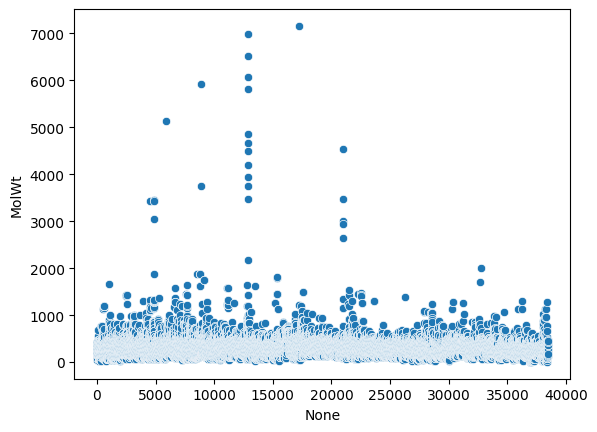

In [47]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["MolWt"])

<Axes: xlabel='None', ylabel='Kappa3'>

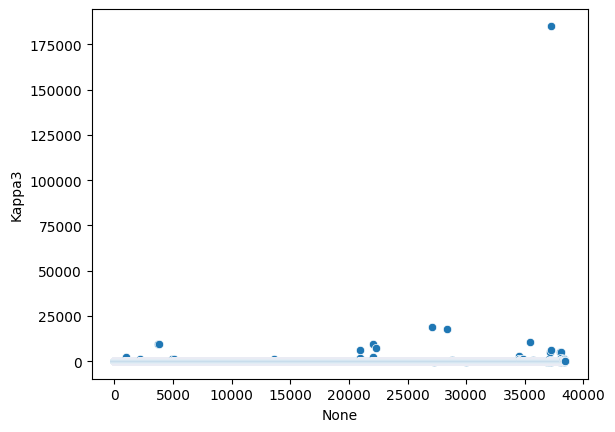

In [48]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["Kappa3"])

<Axes: xlabel='None', ylabel='NumAliphaticHeterocycles'>

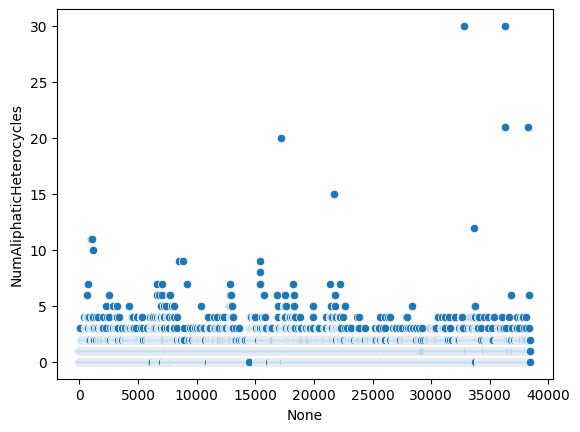

In [49]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["NumAliphaticHeterocycles"])

<Axes: xlabel='None', ylabel='fr_para_hydroxylation'>

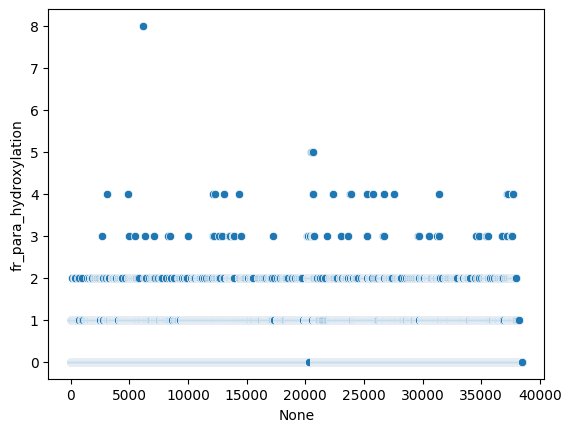

In [50]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["fr_para_hydroxylation"])

WE CAN SEE ALL THE DATAS ARE IN DIFFERENT DIFFERENT RANGE SO WE WILL SCALE IT

<Axes: ylabel='MolWt'>

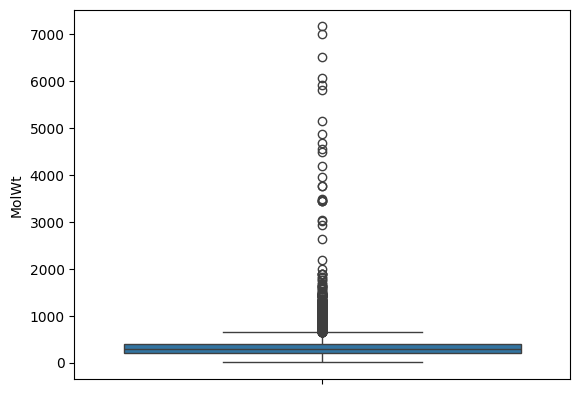

In [51]:
sns.boxplot(
    y=X_train_clean["MolWt"]

)

<Axes: ylabel='Kappa3'>

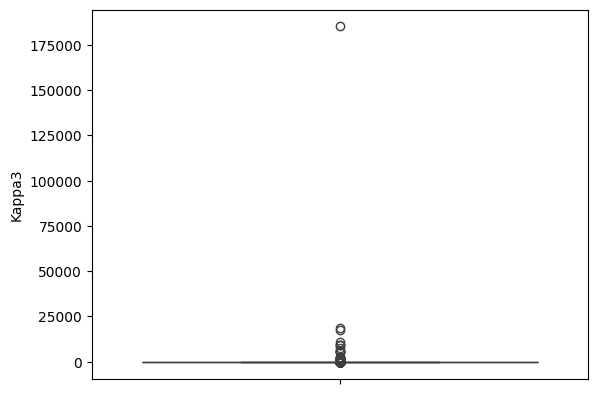

In [52]:
sns.boxplot(
    y=X_train_clean["Kappa3"],

)

<Axes: xlabel='MolWt', ylabel='Count'>

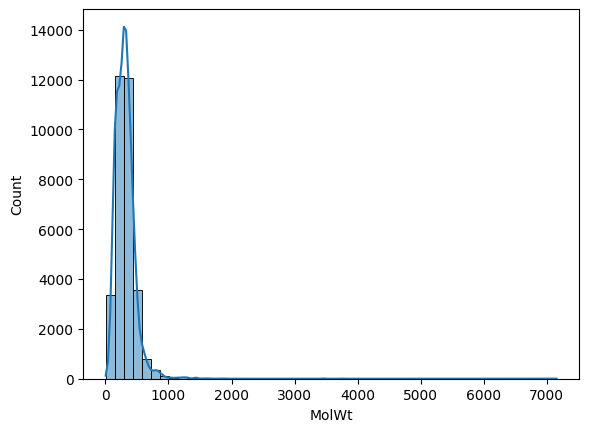

In [53]:
sns.histplot(X_train_clean["MolWt"], bins=50, kde=True)

THIS IS RIGHT SKEWED

In [54]:
X_train_log = X_train_clean.copy()
X_val_log = X_val_clean.copy()
X_test_log = X_test_clean.copy()

In [55]:
#columns for log transformation
fingerprints_cols = [col for col in X_train_clean.columns if col.startswith('FP_')]
desc_cols = [col for col in X_train_clean.columns if col not in fingerprints_cols]
cols_to_log = []
for col in desc_cols:
    # Check if the minimum value in the training set is >= 0
    if X_train_clean[col].min() >= 0:
        cols_to_log.append(col)

In [56]:
#  Apply the log transform ONLY to those specific columns
for col in cols_to_log:
    X_train_log[col] = np.log1p(X_train_clean[col])
    X_val_log[col]   = np.log1p(X_val_clean[col])
    X_test_log[col]  = np.log1p(X_test_clean[col])

In [57]:
from sklearn.preprocessing import StandardScaler
import numpy as np # Ensure numpy is imported

fingerprints_cols = [col for col in X_train_clean.columns if col.startswith('FP_')]
desc_cols = [col for col in X_train_clean.columns if col not in fingerprints_cols]

# Replace infinite values (which might have been created by np.log1p) with NaN,
# then fill any NaN values (including those just created) with 0
for df_log in [X_train_log, X_val_log, X_test_log]:
    df_log.replace([np.inf, -np.inf], np.nan, inplace=True)


scaler = StandardScaler()

#scaling only the descriptor columns, leaving the binary fingerprint columns unchanged
X_train_desc_scaled = scaler.fit_transform(X_train_log[desc_cols])
X_val_desc_scaled = scaler.transform(X_val_log[desc_cols])
X_test_desc_scaled = scaler.transform(X_test_log[desc_cols])

# Convert back to DataFrames with original column names and indices
X_train_desc_scaled = pd.DataFrame(X_train_desc_scaled, columns=desc_cols, index=X_train_log.index)
X_val_desc_scaled = pd.DataFrame(X_val_desc_scaled, columns=desc_cols, index=X_val_log.index)
X_test_desc_scaled = pd.DataFrame(X_test_desc_scaled, columns=desc_cols, index=X_test_log.index)

# 5. Recombine the unscaled fingerprints with the newly scaled descriptors
X_train_ann = pd.concat([X_train_log[fingerprints_cols], X_train_desc_scaled], axis=1)
X_val_ann = pd.concat([X_val_log[fingerprints_cols], X_val_desc_scaled], axis=1)
X_test_ann = pd.concat([X_test_log[fingerprints_cols], X_test_desc_scaled], axis=1)

In [58]:
X_train_ann

,FP_1,FP_2,FP_4,FP_5,FP_7,FP_8,FP_9,FP_11,FP_12,FP_13,...,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,Elec_MaxCharge,Elec_MinCharge
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,1.379429,-0.182716,-1.592286,3.259913
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.867073,2.997985
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.867073,2.997985
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.867073,2.997985
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.867073,2.997985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38453,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,0.644801,-0.539452
38454,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,0.644801,-0.539452
38456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,1.023450,-0.355172
38457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,1.023528,-0.353081


In [59]:
X_val_ann

,FP_1,FP_2,FP_4,FP_5,FP_7,FP_8,FP_9,FP_11,FP_12,FP_13,...,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,Elec_MaxCharge,Elec_MinCharge
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.867073,2.997985
21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.616448,2.355326
22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.658061,2.352186
29,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.656035,2.324751
34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.168425,0.261843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,-1.065469,0.104823
38442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,3.698418,-0.20199,-0.139368,-0.170992,1.379429,-0.182716,0.468344,-0.539461
38448,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,0.644801,-0.539452
38451,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.328361,-0.192003,-0.247884,-0.20199,-0.139368,-0.170992,-0.248881,-0.182716,0.644801,-0.539452


<Axes: xlabel='None', ylabel='MolWt'>

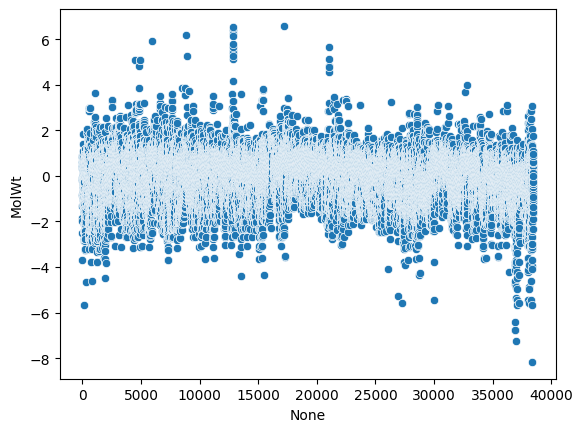

In [60]:
sns.scatterplot(x=X_train_ann.index, y=X_train_ann["MolWt"])

<Axes: ylabel='MolWt'>

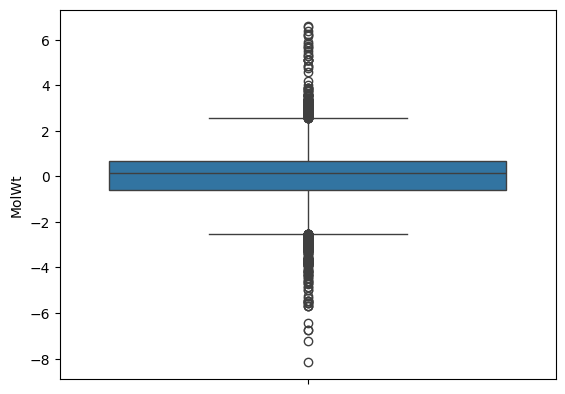

In [61]:
sns.boxplot(
    y=X_train_ann["MolWt"]

)

<Axes: xlabel='MolWt', ylabel='Count'>

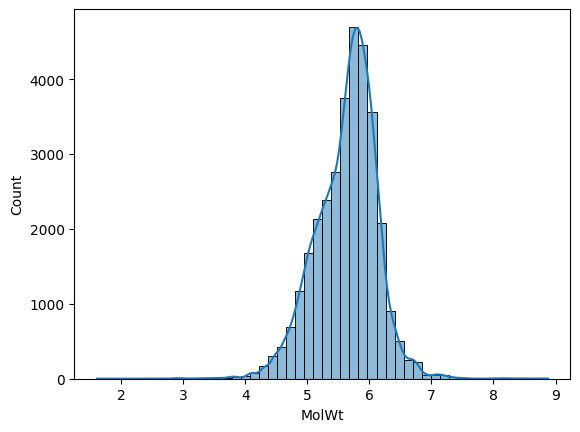

In [62]:
sns.histplot(X_train_log["MolWt"], bins=50, kde=True)

In [63]:
from sklearn.impute import SimpleImputer
import joblib

X_train_np = X_train_ann.to_numpy(dtype=np.float32)
X_val_np = X_val_ann.to_numpy(dtype=np.float32)
X_test_np = X_test_ann.to_numpy(dtype=np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)


X_train_np[np.isinf(X_train_np)] = np.nan
X_val_np[np.isinf(X_val_np)] = np.nan
X_test_np[np.isinf(X_test_np)] = np.nan

imputer = SimpleImputer(strategy='median')
X_train_np = imputer.fit_transform(X_train_np)
X_val_np = imputer.transform(X_val_np)
X_test_np = imputer.transform(X_test_np)

joblib.dump(imputer, 'median_imputer.pkl')

['median_imputer.pkl']

In [64]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



model = Sequential([

    Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],), kernel_regularizer=l2(0.002)),
    BatchNormalization(),

    Dropout(0.4),

    Dense(64, activation='relu', kernel_regularizer=l2(0.002)),
    BatchNormalization(),

    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(0.002)),
    BatchNormalization(),

    Dropout(0.2),

    Dense(13, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
#Count the number of Positives (1s) and Negatives (0s) for each of the 13 columns

pos_counts = np.nansum(y_train_np == 1.0, axis=0)
neg_counts = np.nansum(y_train_np == 0.0, axis=0)


pos_weights = neg_counts / (pos_counts + 1e-7)



# 3. Convert it to a TensorFlow constant so the GPU can use it incredibly fast
tf_pos_weights = tf.constant(pos_weights, dtype=tf.float32)

print("Calculated Weights for 25 labels!")
print("Example Weight for Label 0:", pos_weights[2])

Calculated Weights for 25 labels!
Example Weight for Label 0: 1.314676616751906


In [66]:
# import tensorflow as tf

# def masked_bce_loss(y_true, y_pred):
#     """
#     Computes Binary Crossentropy but completely ignores NaN values in y_true.
#     """
#     y_true = tf.cast(y_true, tf.float32)
#     mask = tf.cast(tf.math.logical_not(tf.math.is_nan(y_true)), tf.float32)
#     y_true_safe = tf.where(tf.math.is_nan(y_true), tf.zeros_like(y_true), y_true)
#     raw_loss = tf.keras.backend.binary_crossentropy(y_true_safe, y_pred)
#     weight_mask = (y_true_safe * tf_pos_weights) + (1.0 - y_true_safe)
#     weighted_loss = raw_loss * weight_mask
#     masked_loss = weighted_loss * mask
#     return tf.reduce_sum(masked_loss, axis=-1) / (tf.reduce_sum(mask, axis=-1) + 1e-7)

In [67]:
import tensorflow as tf

def get_masked_focal_loss(gamma=2.0):
    """
    Returns a Masked Focal Loss function.
    Gamma controls how heavily the model focuses on hard examples.
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        #  Create mask to ignore NaNs
        mask = tf.cast(tf.math.logical_not(tf.math.is_nan(y_true)), tf.float32)
        y_true_safe = tf.where(tf.math.is_nan(y_true), tf.zeros_like(y_true), y_true)

        #  Clip predictions to prevent log(0) which causes NaN gradients
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        #  Calculate raw Binary Cross-Entropy
        bce = - (y_true_safe * tf.math.log(y_pred) + (1.0 - y_true_safe) * tf.math.log(1.0 - y_pred))

        #  Calculate Focal Modulating Factor: (1 - p_t)^gamma
        # p_t is the probability the model assigned to the *actual* correct class
        p_t = y_true_safe * y_pred + (1.0 - y_true_safe) * (1.0 - y_pred)
        focal_modulator = tf.math.pow(1.0 - p_t, gamma)

        #  Apply the existing static Class Imbalance Weights
        # (Assumes tf_pos_weights is available in global scope)
        weight_mask = (y_true_safe * tf_pos_weights) + (1.0 - y_true_safe)

        #  Combine all factors: Modulator * BCE * Class_Weight
        focal_loss = focal_modulator * bce * weight_mask

        #  Apply NaN mask and calculate the mean over valid tests only
        masked_loss = focal_loss * mask
        return tf.reduce_sum(masked_loss, axis=-1) / (tf.reduce_sum(mask, axis=-1) + 1e-7)

    return loss



In [68]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=get_masked_focal_loss(gamma=2.0),
    metrics=[

        tf.keras.metrics.AUC(multi_label=True, name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)




In [69]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [70]:
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [71]:
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [72]:
history = model.fit(
    X_train_np,
    y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopper, lr_reducer],
    verbose=1
)

Epoch 1/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - auc: 0.5485 - loss: 0.6502 - precision: 0.9145 - recall: 0.5122 - val_auc: 0.6214 - val_loss: 0.3941 - val_precision: 0.9383 - val_recall: 0.5025 - learning_rate: 0.0010
Epoch 2/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.5793 - loss: 0.3138 - precision: 0.9302 - recall: 0.5119 - val_auc: 0.6453 - val_loss: 0.2419 - val_precision: 0.9516 - val_recall: 0.5136 - learning_rate: 0.0010
Epoch 3/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.6021 - loss: 0.2135 - precision: 0.9373 - recall: 0.5043 - val_auc: 0.6563 - val_loss: 0.1880 - val_precision: 0.9522 - val_recall: 0.5199 - learning_rate: 0.0010
Epoch 4/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.6093 - loss: 0.1775 - precision: 0.9404 - recall: 0.5019 - val_auc: 0.6465 - val_loss: 0.1675 - val_precision: 0.9459 - val_recall: 0.5242 - learning_rate: 0.0010
Epoch 5/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.6178 - loss: 0.1653 - precision: 0.9

In [73]:
y_val_pred_prob = model.predict(X_val_np)

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [74]:
from sklearn.metrics import fbeta_score
import numpy as np

best_thresholds_strict = []
BETA = 0.7

for i in range(y_val_np.shape[1]):

    y_true = y_val_np[:, i]
    y_pred_prob = y_val_pred_prob[:, i]

    # Remove NaNs
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_pred_prob = y_pred_prob[mask]

    best_t = 0.5
    best_fbeta = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (y_pred_prob > t).astype(int)

        if len(np.unique(y_true)) < 2:
            continue  # skip bad labels


        fbeta = fbeta_score(y_true, preds, beta=BETA, zero_division=0)

        if fbeta > best_fbeta:
            best_fbeta = fbeta
            best_t = t

    best_thresholds_strict.append(best_t)

print(f"Best thresholds per label (Optimized for F{BETA}):")
print(best_thresholds_strict)

threshold_dict = {label: float(thresh) for label, thresh in zip(label_cols, best_thresholds_strict)}


with open('optimal_thresholds.json', 'w') as f:
    json.dump(threshold_dict, f, indent=4)

print("Optimal F0.7 thresholds safely stored to optimal_thresholds.json")






Best thresholds per label (Optimized for F0.7):
[np.float64(0.5000000000000001), np.float64(0.5500000000000002), np.float64(0.6000000000000002), np.float64(0.6000000000000002), np.float64(0.5000000000000001), np.float64(0.6000000000000002), np.float64(0.7500000000000002), np.float64(0.5500000000000002), np.float64(0.6500000000000001), np.float64(0.6000000000000002), np.float64(0.6000000000000002), np.float64(0.6500000000000001), np.float64(0.6000000000000002)]
Optimal F0.7 thresholds safely stored to optimal_thresholds.json


In [75]:
y_val_pred = np.zeros_like(y_val_pred_prob)

for i, t in enumerate(best_thresholds_strict):
    y_val_pred[:, i] = (y_val_pred_prob[:, i] > t).astype(int)

In [76]:
from sklearn.metrics import precision_score, recall_score

# Apply the new strict thresholds
y_val_pred_strict = np.zeros_like(y_val_pred_prob)

for i, t in enumerate(best_thresholds_strict):
    y_val_pred_strict[:, i] = (y_val_pred_prob[:, i] > t).astype(int)

precision_list = []
recall_list = []
fbeta_list = []

for i in range(y_val_np.shape[1]):

    y_true = y_val_np[:, i]
    y_pred = y_val_pred_strict[:, i]

    # Remove NaNs
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(np.unique(y_true)) < 2:
        precision_list.append(np.nan)
        recall_list.append(np.nan)
        fbeta_list.append(np.nan)
        continue

    precision_list.append(precision_score(y_true, y_pred, zero_division=0))
    recall_list.append(recall_score(y_true, y_pred, zero_division=0))
    fbeta_list.append(fbeta_score(y_true, y_pred, beta=BETA, zero_division=0))

# Print the final report
for i, name in enumerate(label_cols):
    print(f"{name}:")
    print(f"  Threshold: {best_thresholds_strict[i]:.2f}")
    print(f"  Precision: {precision_list[i]:.3f}")
    print(f"  Recall:    {recall_list[i]:.3f}")
    print(f"  F{BETA}:      {fbeta_list[i]:.3f}")
    print("------")

Hepatotoxic:
  Threshold: 0.50
  Precision: 0.679
  Recall:    0.809
  F0.7:      0.717
------
Cardiotoxicity:
  Threshold: 0.55
  Precision: 0.895
  Recall:    0.825
  F0.7:      0.871
------
Respiratory_toxicity:
  Threshold: 0.60
  Precision: 0.889
  Recall:    0.696
  F0.7:      0.814
------
BBBP_toxicity:
  Threshold: 0.60
  Precision: 0.968
  Recall:    0.859
  F0.7:      0.929
------
Mutagenicity:
  Threshold: 0.50
  Precision: 0.852
  Recall:    0.862
  F0.7:      0.855
------
Eye Irritation:
  Threshold: 0.60
  Precision: 0.934
  Recall:    0.934
  F0.7:      0.934
------
Eye Corrosion:
  Threshold: 0.75
  Precision: 0.926
  Recall:    0.735
  F0.7:      0.853
------
Carcinogenicity:
  Threshold: 0.55
  Precision: 0.755
  Recall:    0.688
  F0.7:      0.731
------
CYP450_CYP1A2:
  Threshold: 0.65
  Precision: 0.911
  Recall:    0.772
  F0.7:      0.860
------
CYP450_CYP2C9:
  Threshold: 0.60
  Precision: 0.756
  Recall:    0.731
  F0.7:      0.747
------
CYP450_CYP2C19:
  Thre

In [77]:
import joblib
import json

#  Save the Keras Neural Network
model.save('toxicity_model.h5')

#  Save the Scaler
joblib.dump(scaler, 'desc_scaler.pkl')

#  Save the exact column order and metadata
pipeline_metadata = {
    'fingerprints_cols': fingerprints_cols,
    'desc_cols': desc_cols,
    'cols_to_log': cols_to_log,
    'label_names': list(label_cols)
}

with open('pipeline_metadata.json', 'w') as f:
    json.dump(pipeline_metadata, f, indent=4)


In [78]:
from sklearn.metrics import precision_score, recall_score, fbeta_score

# Predict raw probabilities on the unseen TEST set
y_test_pred_prob = model.predict(X_test_np)

# Apply the strict thresholds you just learned from the VAL set
y_test_pred_strict = np.zeros_like(y_test_pred_prob)
for i, t in enumerate(best_thresholds_strict):
    y_test_pred_strict[:, i] = (y_test_pred_prob[:, i] > t).astype(int)

#  Generate the true Final Exam report
print("TRUE UNBIASED TEST SET PERFORMANCE ")
for i, name in enumerate(label_cols):
    y_true = y_test_np[:, i]
    y_pred = y_test_pred_strict[:, i]

    # Remove NaNs
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(np.unique(y_true)) < 2:
        continue

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f07 = fbeta_score(y_true, y_pred, beta=0.7, zero_division=0)

    print(f"{name}:")
    print(f"  Applied Val Threshold: {best_thresholds_strict[i]:.2f}")
    print(f"  True Test Precision:   {precision:.3f}")
    print(f"  True Test Recall:      {recall:.3f}")
    print(f"  True Test F0.7:        {f07:.3f}")
    print("------")

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
TRUE UNBIASED TEST SET PERFORMANCE 
Hepatotoxic:
  Applied Val Threshold: 0.50
  True Test Precision:   0.688
  True Test Recall:      0.775
  True Test F0.7:        0.714
------
Cardiotoxicity:
  Applied Val Threshold: 0.55
  True Test Precision:   0.891
  True Test Recall:      0.831
  True Test F0.7:        0.870
------
Respiratory_toxicity:
  Applied Val Threshold: 0.60
  True Test Precision:   0.935
  True Test Recall:      0.763
  True Test F0.7:        0.871
------
BBBP_toxicity:
  Applied Val Threshold: 0.60
  True Test Precision:   0.914
  True Test Recall:      0.821
  True Test F0.7:        0.881
------
Mutagenicity:
  Applied Val Threshold: 0.50
  True Test Precision:   0.804
  True Test Recall:      0.839
  True Test F0.7:        0.815
------
Eye Irritation:
  Applied Val Threshold: 0.60
  True Test Precision:   0.956
  True Test Recall:      0.928
  True Test F0.7:        0.946
------
Eye Corrosion:
  Applied Val Threshold: 0.75
  Tr

In [79]:
import json
import numpy as np
import pandas as pd

# Read the exact column names  previously saved model expects
with open('pipeline_metadata.json', 'r') as f:
    meta = json.load(f)

expected_fps = meta['fingerprints_cols']
expected_desc = meta['desc_cols']
exact_features = expected_fps + expected_desc

print(f"Your saved model expects exactly {len(exact_features)} columns.")

#  Slice dataframe to match ONLY those exact 1743 columns
X_train_exact = X_train_ann[exact_features].copy()

#  Apply the imputer to handle NaNs
X_train_np_exact = imputer.transform(X_train_exact.to_numpy(dtype=np.float32))


np.random.seed(42)
background_idx = np.random.choice(X_train_np_exact.shape[0], 200, replace=False)
shap_background = X_train_np_exact[background_idx]

np.save('shap_background.npy', shap_background)
print(f"SUCCESS: Saved shap_background.npy with shape: {shap_background.shape}")



Your saved model expects exactly 1743 columns.
SUCCESS: Saved shap_background.npy with shape: (200, 1743)


In [80]:

print("Model mathematically synced to 165 columns!")

Model mathematically synced to 165 columns!


In [81]:


#. Create a clean copy of the dataset with just SMILES and Labels
kb_df = final_dataset[['SMILES'] + label_cols].copy()
kb_df[label_cols] = kb_df[label_cols].fillna(0)

#  Generate raw 2048 Morgan Fingerprints for the database
print("Generating raw 2048-bit fingerprints for the Tanimoto Database...")
generator = GetMorganGenerator(radius=3, fpSize=2048)

fp_list = []
for smi in kb_df['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp_list.append(generator.GetFingerprintAsNumPy(mol))
    else:
        fp_list.append(np.zeros(2048))

#  Add them to the dataframe
fp_df = pd.DataFrame(fp_list, columns=[f"FP_{i}" for i in range(2048)], index=kb_df.index)
kb_final = pd.concat([kb_df, fp_df], axis=1)

# Save the perfectly formatted database
kb_final.to_parquet('fingerprint_knowledge_base.parquet', index=False)
print(f"SUCCESS: Saved Knowledge Base with {len(kb_final)} molecules and exactly 2048 fingerprint bits!")

Generating raw 2048-bit fingerprints for the Tanimoto Database...
SUCCESS: Saved Knowledge Base with 38459 molecules and exactly 2048 fingerprint bits!
